In [1]:
%load_ext autoreload
%autoreload 2

# Fiducial vs epsilon-scaled orbits: z=0 comparison

Compares the fiducial (no orbit perturbation) and epsilon-scaled-orbit
merger-tree samples for the 13.0 mass bin, produced by
`SatGen/notebooks/claude_based/epsilon_ratio_orbit_init.py` (the epsilon
perturbation) and `MassSpec/src/epsilon_orbits/run_abundance.py` (the
abundance measurements -> `fiducial.h5` and `epsilon.h5`), processed into
`data/epsilon/prelim/epsilon_z0.csv` / `fiducial_z0.csv` with
`jsm_processh5.ProcessH5`.

`logc` is `ProcessH5(..., conctype=None)` -- the *analytic* Zhao et al.
(2009) host concentration (`host_c` in the raw h5, matching
`conctype='zhao'` set in `SatGen/src/jsm_SubGen_masspec.py` when these
trees were generated), not `conctype="measured"` (fit to each tree's
realized density profile) or `conctype="ludlow"`. Being the analytic,
mass-only value it's identical between the fiducial and epsilon samples
for the same `tree_index` -- verified 2026-08-28 (this CSV previously
shipped with `conctype="measured"` by default and was regenerated, same
as the bolshoi_rep CSVs -- see `notebooks/paper3/bolshoi_rep.ipynb`).

Modeled after `MassSpec/notebooks/paper3/satgen_bolshoi.ipynb`'s
`plot_corner_with_corr` comparison, adapted for two SatGen samples (rather
than SatGen vs Bolshoi) and generalized to take an arbitrary pair of
model labels/suffixes.

In [2]:
import itertools
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_stats

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0  # inches
single_textwidth = 3.5  # inches
levelz = [1 - 0.99, 1 - 0.95, 1 - 0.68]  # contour levels, matches satgen_bolshoi.ipynb

In [4]:
epsilon_df = pd.read_csv("../../data/epsilon/prelim/epsilon_z0.csv")

fiducial_df = pd.read_csv("../../data/epsilon/prelim/fiducial_z0.csv")

## Corner plot: fiducial vs epsilon

Same panel layout as `satgen_bolshoi.ipynb`'s `plot_corner_with_corr`
(diagonal = 1D KDE marginals, lower triangle = 2D KDE contours + Spearman
$\rho$ annotated per model), generalized to take an arbitrary list of
`(suffix, label)` models instead of hardcoded SatGen/Bolshoi. `logMvir` is
left out of the panel keys since both samples are the single 13.0 mass
bin (no spread to show).

The two models are paired by `tree_index` (an inner merge) rather than by
mass bin like the SatGen-vs-Bolshoi comparison -- `epsilon.h5` and
`fiducial.h5` are the *same* underlying trees, just with/without the
orbit perturbation, so pairing on `tree_index` compares each tree to
itself across the two runs (and naturally drops any tree that errored out
in one run but not the other).

In [5]:
def plot_corner_with_corr(matched, models, keys, paramNames, colors=("steelblue", "darkorange"),
                           paramRanges=None, figsize=14):
    """
    Corner comparison between two models using a matched dataframe, with
    Spearman correlation coefficients annotated in each off-diagonal panel.

    models : list of (suffix, label) tuples, e.g. [("fid", "fiducial"), ("eps", "epsilon")]
    keys   : column base-names to compare, expected in matched as f"{key}_{suffix}"
    paramRanges : list of [lo, hi] per key, or None to auto-range from the data (1st/99th percentile + 5% pad)
    """

    model_colors = dict(zip([m for _, m in models], colors))

    model_chains = {}
    model_rho = {}

    for suffix, model in models:
        cols = [f"{k}_{suffix}" for k in keys]
        chain = matched[cols].copy()
        chain.columns = keys

        mask = ~chain.isna().any(axis=1)
        chain = chain.loc[mask].reset_index(drop=True)

        pair_rho = {}
        for k1, k2 in itertools.combinations(keys, 2):
            pair_rho[(k1, k2)] = jsm_stats.correlation(chain[k1].values, chain[k2].values)

        model_chains[model] = chain
        model_rho[model] = pair_rho

    if paramRanges is None:
        paramRanges = []
        for k in keys:
            allvals = np.concatenate([model_chains[m][k].values for _, m in models])
            allvals = allvals[np.isfinite(allvals)]
            lo, hi = np.nanpercentile(allvals, [1, 99])
            pad = 0.5 * (hi - lo if hi > lo else 1.0)
            paramRanges.append([lo - pad, hi + pad])

    nDim = len(keys)
    fig, axes = plt.subplots(nDim, nDim, figsize=(double_textwidth, double_textwidth))

    for i in range(nDim):
        for j in range(nDim):
            ax = axes[i, j]

            if j > i:
                ax.axis("off")
                continue

            if i == j:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(chain[keys[i]], ax=ax, color=model_colors[model], fill=False, lw=1.8)
                ax.set_xlim(paramRanges[i])
                ax.set_yticks([])

            else:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(x=chain[keys[j]], y=chain[keys[i]], ax=ax, color=model_colors[model],
                                levels=levelz, fill=False, linewidths=1.3)
                ax.set_xlim(paramRanges[j])
                ax.set_ylim(paramRanges[i])

                pair = (keys[j], keys[i])
                first_model = models[0][1]
                if pair not in model_rho[first_model]:
                    pair = (keys[i], keys[j])

                y0 = 0.85
                for _, model in models:
                    rho = model_rho[model][pair]
                    ax.text(0.7, y0, "$\\rho$=" + f"{rho:.2f}", transform=ax.transAxes, fontsize=10,
                            color=model_colors[model],
                            bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="k"))
                    y0 -= 0.15

            if i < nDim - 1:
                ax.set_xticklabels([])
                ax.set_xlabel("")
            else:
                ax.set_xlabel(paramNames[j], fontsize=12, fontfamily="Times")

            if j > 0 or i == j:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            else:
                ax.set_ylabel(paramNames[i], fontsize=12, fontfamily="Times")

            ax.tick_params(labelsize=10)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontfamily("Times")

    handles = [plt.Line2D([0], [0], color=model_colors[model], lw=1.8, label=model) for _, model in models]
    fig.legend(handles=handles, loc="upper right", fontsize=12, frameon=False)

    plt.subplots_adjust(wspace=0.08, hspace=0.08)
    plt.tight_layout()
    return fig

1000 trees matched by tree_index (of 1000 fiducial / 1000 epsilon)


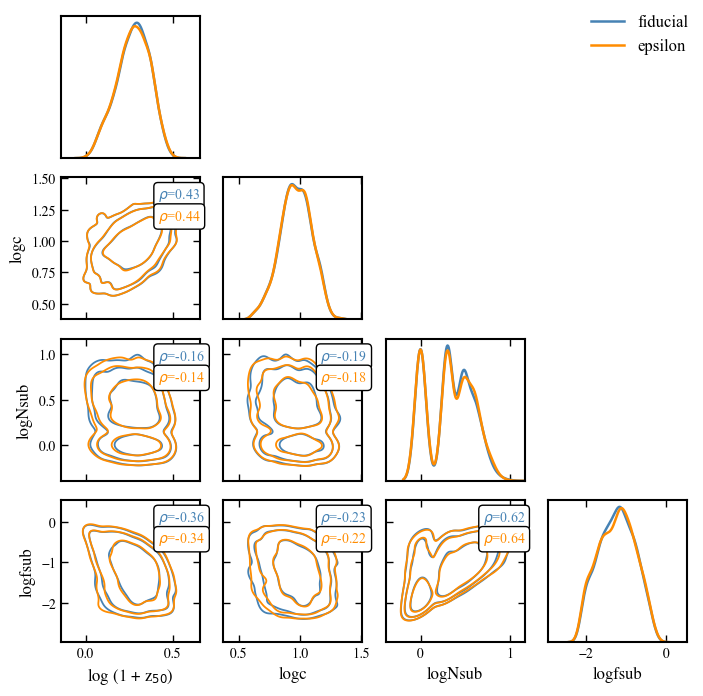

In [6]:
matched = fiducial_df.merge(epsilon_df, on="tree_index", how="inner", suffixes=("_fid", "_eps"))
print(f"{len(matched)} trees matched by tree_index (of {len(fiducial_df)} fiducial / {len(epsilon_df)} epsilon)")

keys = ["log1pz50", "logc", "logNsub", "logfsub"]
paramNames = ["log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"]
models = [("fid", "fiducial"), ("eps", "epsilon")]

fig = plot_corner_with_corr(matched, models=models, keys=keys, paramNames=paramNames,
                             colors=("steelblue", "darkorange"), figsize=double_textwidth)
# fig.savefig("../../figures/epsilon_vs_fiducial_corner.pdf", bbox_inches="tight")  # not auto-saving to disk -- left inline only


<Axes: xlabel='fsub_fid', ylabel='Density'>

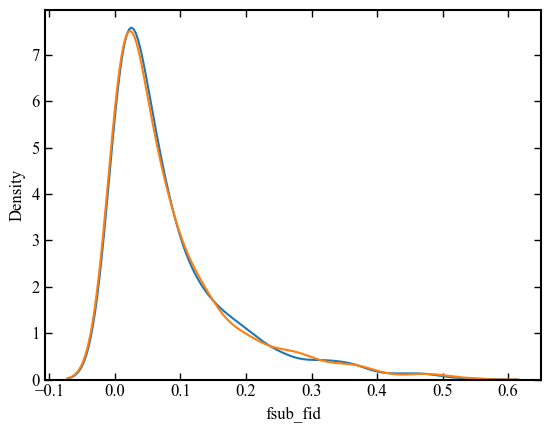

In [7]:
sns.kdeplot(matched["fsub_fid"])
sns.kdeplot(matched["fsub_eps"])

## A-scale sweep vs fiducial: z=0 comparison

Compares the fiducial sample against a 7-model epsilon *A*-scale sweep
(`A3`, `A6`, `A9`, `A12`, `A15`, `A100`), each produced by
`run_abundance.py --a-sweep` and processed through `ProcessH5` with
`conctype=None` (Zhao et al. 2009), matching the convention used
throughout this notebook.

**Two notes on the model set, both confirmed with Sebastian:**
- `A1` was on disk (`scale_A1.h5`) but is an empty file (0 tree groups,
  ~800 bytes) -- it is **skipped** here.
- The originally requested set named `A5`, but no `scale_A5.h5` exists;
  `scale_A6.h5` does exist and is used in its place (typo: A5 -> A6).

Final set: **fiducial, A3, A6, A9, A12, A15, A100** (7 models).

With 7 models a single corner plot is too dense to read, so instead this
section shows, for each A-model vs. fiducial, a pair of 2D histogram
panels (`fsub` x `cvir` and `fsub` x `z50`), plus a table of Spearman
rank correlations. All three quantities are used in their
**log-transformed** form (`logfsub`, `logc`, `log1pz50`) -- these are the
columns `ProcessH5` already writes to the CSVs and are what the rest of
this notebook (and `satgen_bolshoi.ipynb`) plots, so this keeps the
convention consistent. Flagging this explicitly in case linear
`fsub`/`cvir`/`z50` was actually wanted instead.


In [8]:
A_labels = ["A3", "A6", "A9", "A12", "A15", "A100"]
sweep_dfs = {A: pd.read_csv(f"../../data/epsilon/scale_{A}_z0.csv") for A in A_labels}

for A in A_labels:
    print(A, sweep_dfs[A].shape)


A3 (1000, 11)
A6 (1000, 11)
A9 (1000, 11)
A12 (1000, 11)
A15 (1000, 11)
A100 (1000, 11)


In [9]:
def add_suffix(df, suf):
    return df.rename(columns={c: f"{c}_{suf}" for c in df.columns if c != "tree_index"})

sweep_models = [("fid", "fiducial")] + [(A, f"A={A[1:]}") for A in A_labels]

sweep_frames = [add_suffix(fiducial_df, "fid")] + [add_suffix(sweep_dfs[A], A) for A in A_labels]
matched_sweep = sweep_frames[0]
for frame in sweep_frames[1:]:
    matched_sweep = matched_sweep.merge(frame, on="tree_index", how="inner")

print(f"{len(matched_sweep)} trees matched across all {len(sweep_models)} models "
      f"(of {len(fiducial_df)} fiducial)")

sweep_comparisons = sweep_models[1:]


1000 trees matched across all 7 models (of 1000 fiducial)


### 2D KDE contours: fsub x cvir and fsub x z50, fiducial vs each A-model

Same contour style as `plot_corner_with_corr` above (2D KDE, levels
matching `levelz`), with the Spearman $\rho$ for each model annotated
directly in its panel rather than in a separate table.


In [21]:
def plot_2d_kde_grid(matched, comparisons, xcol, ycol, xlabel, ylabel,
                      base_suffix="fid", base_label="fiducial",
                      figsize=(12, 7)):
    """
    Grid of 2D KDE contour panels, one per (suffix, label) in
    `comparisons`, each overlaying the fiducial contours (steelblue)
    against that model's contours (darkorange). Spearman rho for both
    the fiducial and the variant are annotated in each panel. `matched`
    must have columns f"{xcol}_{suffix}" / f"{ycol}_{suffix}" for every
    suffix involved.
    """
    allx = pd.concat([matched[f"{xcol}_{base_suffix}"]] + [matched[f"{xcol}_{s}"] for s, _ in comparisons])
    ally = pd.concat([matched[f"{ycol}_{base_suffix}"]] + [matched[f"{ycol}_{s}"] for s, _ in comparisons])
    xrange = (np.nanpercentile(allx, 0.5)-0.5, np.nanpercentile(allx, 99.5)+0.5)
    yrange = (np.nanpercentile(ally, 0.5)-0.5, np.nanpercentile(ally, 99.5)+0.5)

    ncols = 3
    nrows = int(np.ceil(len(comparisons) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    rho_base = jsm_stats.correlation(matched[f"{xcol}_{base_suffix}"].values,
                                      matched[f"{ycol}_{base_suffix}"].values)

    for ax, (suf, label) in zip(axes, comparisons):
        sns.kdeplot(x=matched[f"{xcol}_{base_suffix}"], y=matched[f"{ycol}_{base_suffix}"],
                    levels=levelz, color="steelblue", linewidths=1.3, ax=ax)
        sns.kdeplot(x=matched[f"{xcol}_{suf}"], y=matched[f"{ycol}_{suf}"],
                    levels=levelz, color="darkorange", linewidths=1.3, ax=ax)

        rho_var = jsm_stats.correlation(matched[f"{xcol}_{suf}"].values, matched[f"{ycol}_{suf}"].values)

        ax.text(0.05, 0.92, "$\\rho$=" + f"{rho_base:.2f}", transform=ax.transAxes, fontsize=9,
                color="steelblue", va="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="k"))
        ax.text(0.05, 0.78, "$\\rho$=" + f"{rho_var:.2f}", transform=ax.transAxes, fontsize=9,
                color="darkorange", va="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="k"))

        ax.set_xlim(xrange)
        ax.set_ylim(yrange)
        ax.set_title(label)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    for ax in axes[len(comparisons):]:
        ax.axis("off")

    handles = [plt.Line2D([0], [0], color="steelblue", lw=1.8, label=base_label),
               plt.Line2D([0], [0], color="darkorange", lw=1.8, label="A-variant")]
    fig.legend(handles=handles, loc="upper right")
    plt.tight_layout()
    return fig


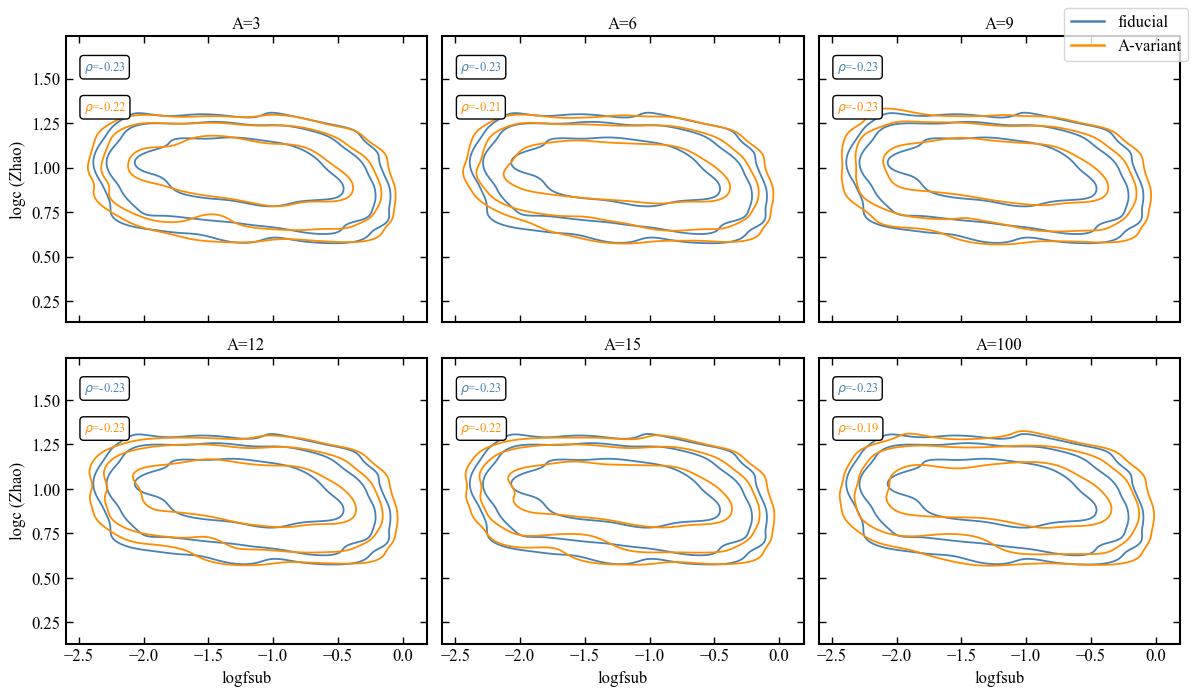

In [22]:
fig_fsub_c = plot_2d_kde_grid(matched_sweep, sweep_comparisons, "logfsub", "logc",
                               "logfsub", "logc (Zhao)")


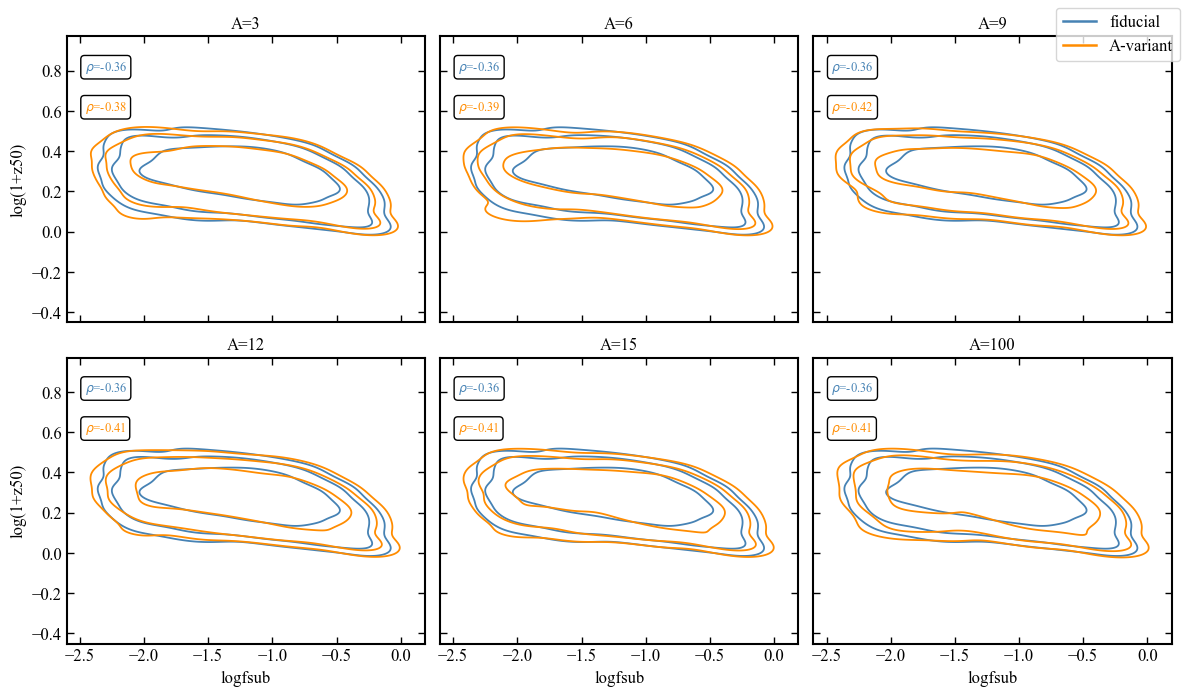

In [23]:
fig_fsub_z50 = plot_2d_kde_grid(matched_sweep, sweep_comparisons, "logfsub", "log1pz50",
                                 "logfsub", "log(1+z50)")


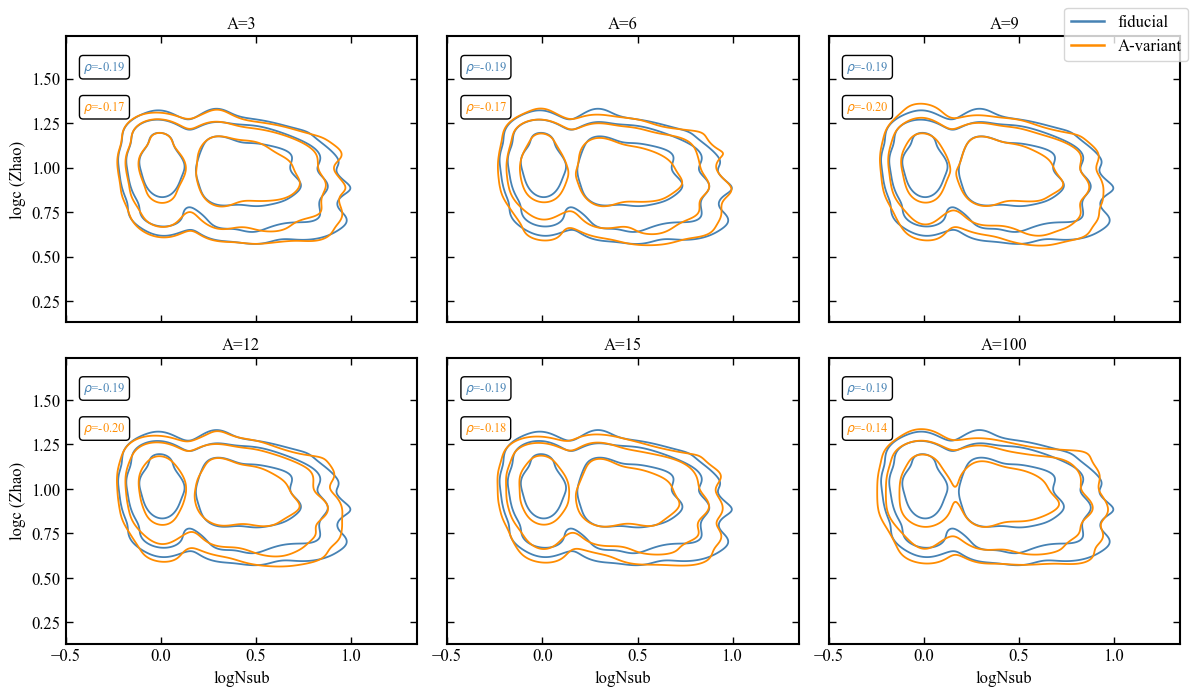

In [24]:
fig_fsub_c = plot_2d_kde_grid(matched_sweep, sweep_comparisons, "logNsub", "logc",
                               "logNsub", "logc (Zhao)")


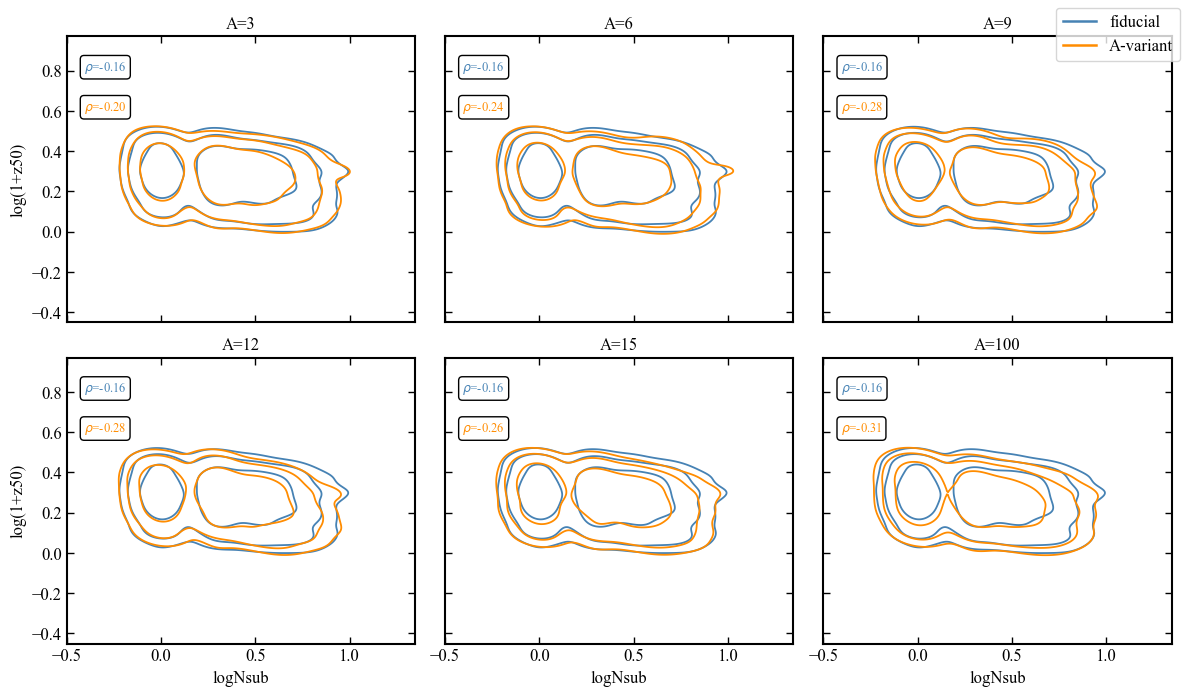

In [25]:
fig_fsub_z50 = plot_2d_kde_grid(matched_sweep, sweep_comparisons, "logNsub", "log1pz50",
                                 "logNsub", "log(1+z50)")


### Rank-order correlation vs. A

Spearman $\rho$ as a function of the *A*-scale parameter, for four
quantity pairs: $\rho_S(N_{\rm sub}\,|\,z_{50})$, $\rho_S(f_{\rm sub}\,|\,z_{50})$,
$\rho_S(N_{\rm sub}\,|\,c_{\rm vir})$, and $\rho_S(f_{\rm sub}\,|\,c_{\rm vir})$.
Includes the fiducial model at `A=0`; `A15` and `A100` are dropped per
request. Error bars are jackknife estimates from
`jsm_stats.jackknife_correlation` (10 subsets, default).


In [ ]:
def rank_corr_vs_A(matched, points, pairs, n_jack=10, figsize=(7, 5)):
    """
    Spearman rank correlation (with jackknife error bars, see
    jsm_stats.jackknife_correlation) as a function of the A-scale
    parameter, for each (xcol, ycol, label, color) in `pairs`.

    points : list of (suffix, A_value) tuples, e.g.
             [("fid", 0), ("A3", 3), ("A6", 6), ...] -- "fid" plots at
             A=0. `matched` must have columns f"{xcol}_{suffix}" /
             f"{ycol}_{suffix}" for every suffix in `points` (e.g.
             matched_sweep).
    """
    A_vals = [v for _, v in points]

    fig, ax = plt.subplots(figsize=figsize)
    for xcol, ycol, label, color in pairs:
        rhos, errs = [], []
        for suf, _ in points:
            x = matched[f"{xcol}_{suf}"].values
            y = matched[f"{ycol}_{suf}"].values
            mask = np.isfinite(x) & np.isfinite(y)
            rho, rho_err, _ = jsm_stats.jackknife_correlation(x[mask], y[mask], n_jack=n_jack)
            rhos.append(rho)
            errs.append(rho_err)
        ax.errorbar(A_vals, rhos, yerr=errs, marker="o", capsize=3, label=label, color=color)

    ax.set_xlabel("A")
    ax.set_ylabel(r"Spearman $\rho$")
    ax.legend()
    plt.tight_layout()
    return fig

rank_corr_points = [("fid", 0)] + [(A, int(A[1:])) for A in A_labels if A not in ("A15", "A100")]

rank_corr_pairs = [
    ("logNsub", "log1pz50", r"$\rho_S(N_{\rm sub}\,|\,z_{50})$", "steelblue"),
    ("logfsub", "log1pz50", r"$\rho_S(f_{\rm sub}\,|\,z_{50})$", "darkorange"),
    ("logNsub", "logc",     r"$\rho_S(N_{\rm sub}\,|\,c_{\rm vir})$", "seagreen"),
    ("logfsub", "logc",     r"$\rho_S(f_{\rm sub}\,|\,c_{\rm vir})$", "firebrick"),
]


In [ ]:
fig_rank_corr = rank_corr_vs_A(matched_sweep, rank_corr_points, rank_corr_pairs)
